DAY 13: THE CAPSTONE INTEGRATION CHALLENGE

In [ ]:
import pandas as pd

#Importing dataset

df=pd.read_csv("dataset.csv")
print("Dataset Preview: \n" , df.head())
print(df.info())
print(df.isnull().sum())

Dataset Preview: 
    age_diff  interest_similarity  communication_style  activity_level  \
0         2                    8                    1               7   
1        10                    2                    0               3   
2         5                    6                    4               3   
3         7                    2                    5               1   
4         5                    2                    8               1   

   personality_match  compatibility  
0                  9              1  
1                  2              0  
2                  7              0  
3                  6              1  
4                  4              1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age_diff             59 non-null     int64
 1   interest_similarity  59 non-null     int64
 2   communication_s

In [ ]:
#Data Preprocessing

X = df.drop("compatibility", axis=1)
y = df["compatibility"]

In [ ]:
# Train-Test Split 

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Polynomial Features

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
#Train Model (Random Forest)

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_poly, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#Predictions

y_pred = model.predict(X_test_poly)

In [ ]:
#Evaluation

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
print("\n===== EVALUATION =====")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


===== EVALUATION =====
Confusion Matrix:
 [[2 2]
 [0 8]]
Accuracy: 0.8333333333333334

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         4
           1       0.80      1.00      0.89         8

    accuracy                           0.83        12
   macro avg       0.90      0.75      0.78        12
weighted avg       0.87      0.83      0.81        12



In [ ]:
#Feature Importance

feature_names = poly.get_feature_names_out()
importance = model.feature_importances_

feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print("\nTop Features:\n", feature_df.head(10))


Top Features:
                                     Feature  Importance
2                       interest_similarity    0.161147
12  interest_similarity communication_style    0.123836
8              age_diff communication_style    0.103470
15                    communication_style^2    0.092243
3                       communication_style    0.078757
11                    interest_similarity^2    0.073241
13       interest_similarity activity_level    0.064113
16       communication_style activity_level    0.060605
17    communication_style personality_match    0.053699
14    interest_similarity personality_match    0.047809


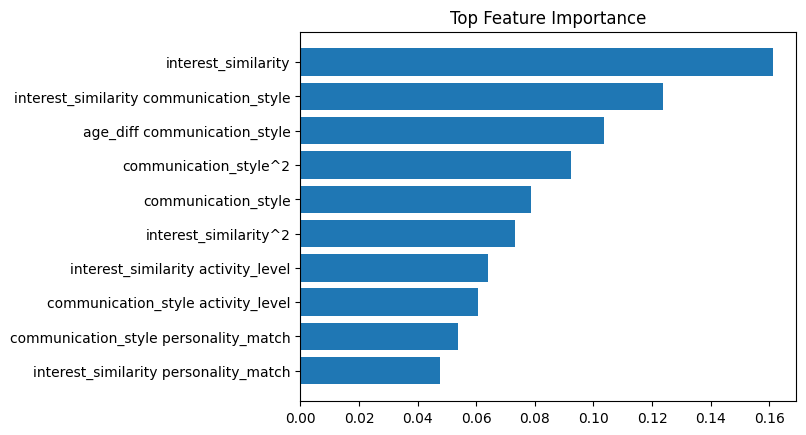

In [ ]:
#Visualization

import matplotlib.pyplot as plt
top_features = feature_df.head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top Feature Importance")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
#Prediction

import warnings
warnings.filterwarnings("ignore")
sample_df = pd.DataFrame([[10, 3, 4, 7, 1]])

sample_poly = poly.transform(sample_df)

prediction = model.predict(sample_poly)

print("\nPrediction:", "Compatible" if prediction[0] == 1 else "Not Compatible")


Prediction: Compatible
